# 1. Exploration du Dataset d'Avis d'Assurance

Ce notebook effectue une analyse exploratoire complète du dataset d'avis d'assurance.

In [1]:
import glob
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

In [2]:
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 1.1 Chargement des données

In [3]:
data_dir = Path('../data/raw/Traduction avis clients')
xlsx_files = sorted(glob.glob(str(data_dir / '*.xlsx')))

In [4]:
if not xlsx_files:
    raise FileNotFoundError(f'Aucun fichier XLSX trouvé dans {data_dir.resolve()}')

dfs = [pd.read_excel(path) for path in xlsx_files]
df = pd.DataFrame(pd.concat(dfs, ignore_index=True))

print(f'Dataset crée')

Dataset crée


In [5]:
TEXT_COL = 'avis'
RATING_COL = 'note'
INSURER_COL = 'assureur'
DATE_COL = 'date_publication'
LENGTH_COL = 'avis_taille'

## 1.2 Vue d'ensemble

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  str    
 2   avis              34435 non-null  str    
 3   assureur          34435 non-null  str    
 4   produit           34435 non-null  str    
 5   type              34435 non-null  str    
 6   date_publication  34435 non-null  str    
 7   date_exp          34435 non-null  str    
 8   avis_en           34433 non-null  str    
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
dtypes: float64(1), object(2), str(8)
memory usage: 26.6+ MB


In [7]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,03/03/2020,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN


In [8]:
df.describe(include='all')

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
count,24104.000000,34434,34435,34435,34435,34435,34435,34435,34433,435,431
unique,NaN,33569,34377,56,13,2,1815,61,33264,435,431
top,NaN,pj-97010,Intervention supprimée à la demande de l'inter...,Direct Assurance,auto,train,02/09/2021,01/09/2021,Loading...,Assurance qui met les clients en difficultés. ...,Insurance that puts customers in difficulty. S...
freq,NaN,5,16,8503,20157,24104,140,2690,1104,1,1
mean,2.847619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.531390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Observations

Données manquantes
- La colonne `note` a à peu près **10 000 valeurs manquantes** → près d'un tiers des avis n'ont pas de note
- La colonne `avis_cor` est quasi vide : seulement **435 avis corrigés** sur 34 435 (~1%)
- `avis_cor_en` est également très peu remplie (431 entrées)

Doublons
- La colonne `avis` contient quelques doublons
- La colonne `avis_en` contient **1 104 entrées avec "Loading..."** — des traductions non effectuées qui polluent les données

Distribution déséquilibrée
- **Direct Assurance** représente à lui seul **8 500 avis** sur 56 assureurs

## 1.3 Distribution des étoiles

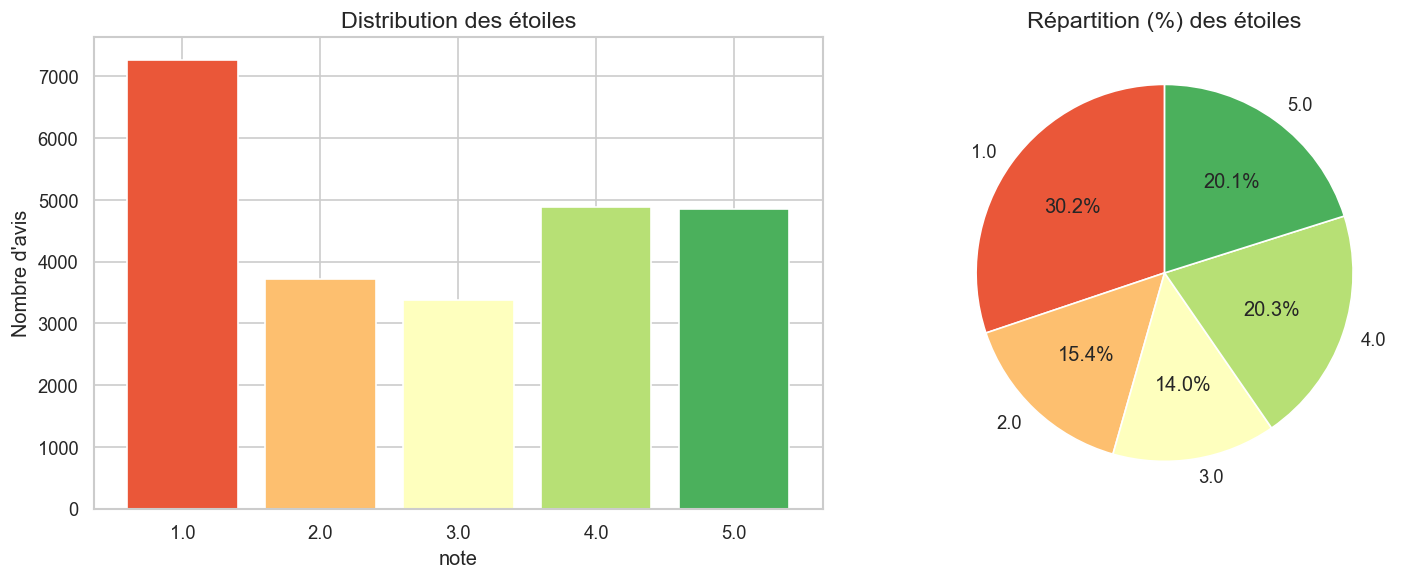

note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64


In [9]:
rating_counts = df[RATING_COL].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
              color=sns.color_palette('RdYlGn', len(rating_counts)))
# ax.bar_label(bars, fmt='%d', padding=3, fontsize=9) => nombre precis des bars
ax.set_title('Distribution des étoiles', fontsize=14)
ax.set_xlabel(RATING_COL)
ax.set_ylabel("Nombre d'avis")

ax2 = axes[1]
ax2.pie(rating_counts.values, labels=rating_counts.index.astype(str),
        autopct='%1.1f%%', colors=sns.color_palette('RdYlGn', len(rating_counts)),
        startangle=90)
ax2.set_title('Répartition (%) des étoiles', fontsize=14)

plt.tight_layout()
plt.show()
print(rating_counts)

## 1.4 Longueur des reviews

In [10]:
df[LENGTH_COL] = df[TEXT_COL].fillna('').apply(len)
print(f'avis_taille ajouter basée sur {TEXT_COL}')
print(df[LENGTH_COL].describe())

avis_taille ajouter basée sur avis
count    34435.000000
mean       345.849194
std        385.472878
min          3.000000
25%        161.000000
50%        201.000000
75%        382.000000
max       8770.000000
Name: avis_taille, dtype: float64


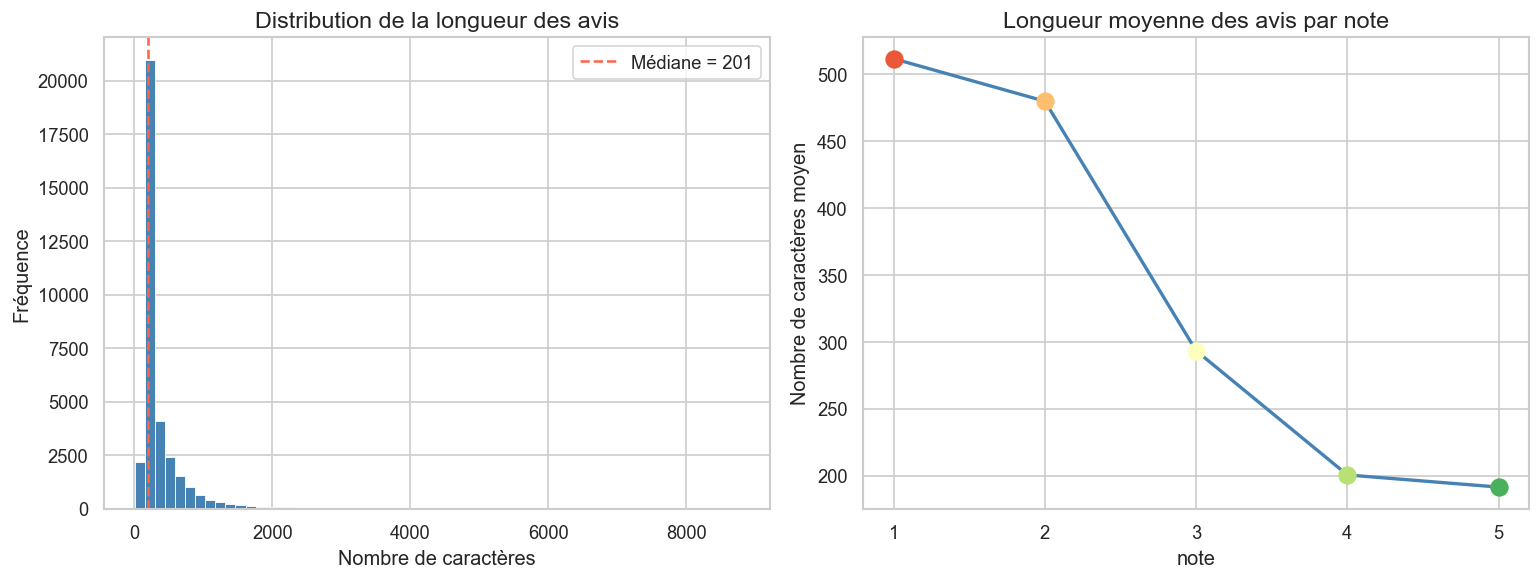

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.hist(df[LENGTH_COL], bins=60, color='steelblue', edgecolor='white', linewidth=0.5)
ax.set_title('Distribution de la longueur des avis', fontsize=14)
ax.set_xlabel('Nombre de caractères')
ax.set_ylabel('Fréquence')
median_len = df[LENGTH_COL].median()
ax.axvline(median_len, color='tomato', linestyle='--', linewidth=1.5, label=f'Médiane = {median_len:.0f}')
ax.legend()

ax2 = axes[1]
mean_by_rating = df.groupby(RATING_COL)[LENGTH_COL].mean().sort_index()
colors = sns.color_palette('RdYlGn', len(mean_by_rating))
ax2.plot(mean_by_rating.index, mean_by_rating.values, marker='o', linewidth=2, color='steelblue')
for x, y, c in zip(mean_by_rating.index, mean_by_rating.values, colors):
    ax2.plot(x, y, marker='o', markersize=10, color=c)
ax2.set_title('Longueur moyenne des avis par note', fontsize=14)
ax2.set_xlabel(RATING_COL)
ax2.set_ylabel('Nombre de caractères moyen')
ax2.set_xticks([1, 2, 3, 4, 5])

plt.tight_layout()
plt.show()

## 1.5 Distribution par assureur

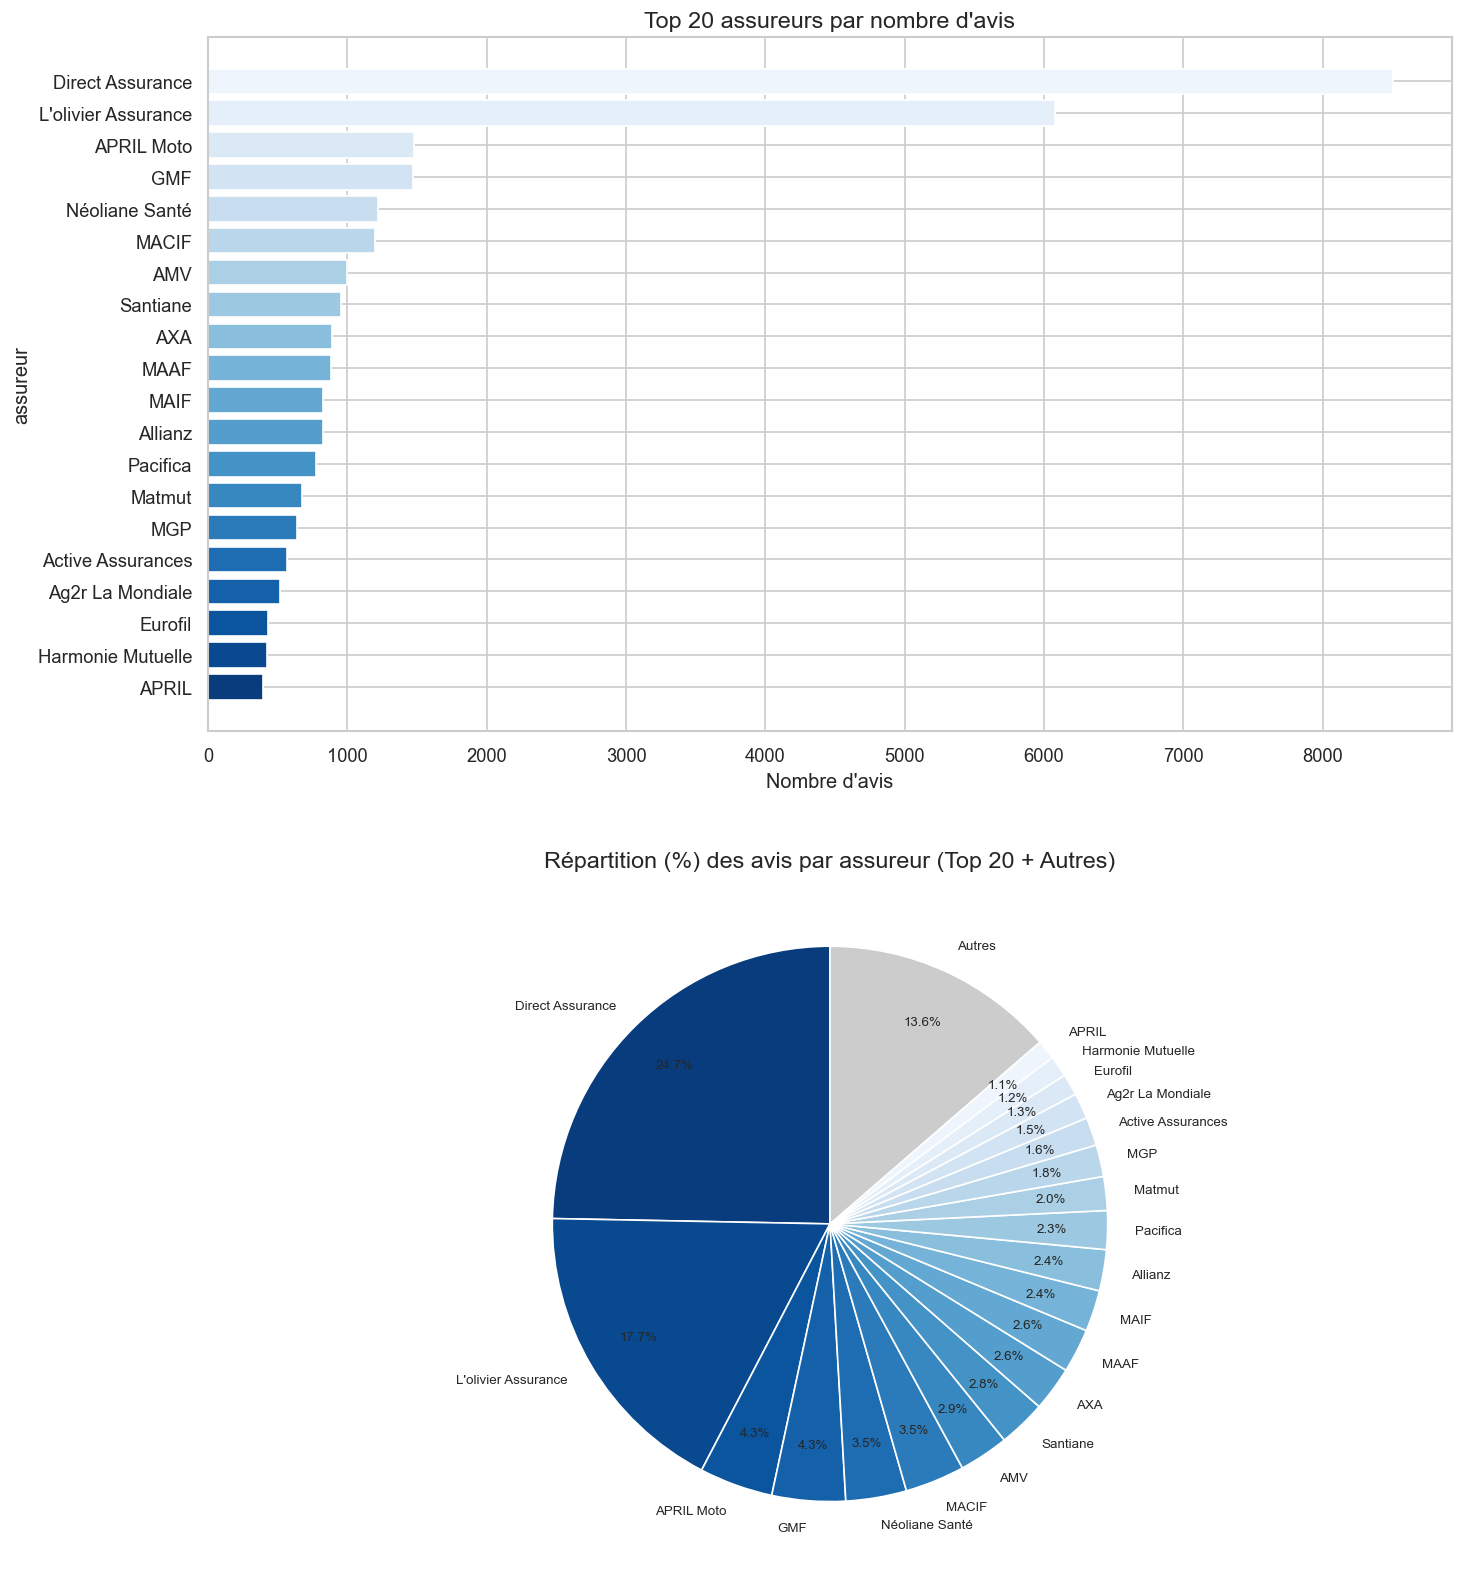

In [12]:
top_n = 20
insurer_counts = df[INSURER_COL].value_counts().head(top_n)

fig, axes = plt.subplots(2, 1, figsize=(13, 14))

# Barplot horizontal
ax = axes[0]
bars = ax.barh(insurer_counts.index[::-1], insurer_counts.values[::-1],
               color=sns.color_palette('Blues_r', top_n))
# ax.bar_label(bars, fmt='%d', padding=3, fontsize=8) => nombre precis des bars
ax.set_title(f'Top {top_n} assureurs par nombre d\'avis', fontsize=14)
ax.set_xlabel('Nombre d\'avis')
ax.set_ylabel(INSURER_COL)

# Camembert
ax2 = axes[1]
others = df[INSURER_COL].value_counts().iloc[top_n:].sum()
pie_values = insurer_counts.to_list() + ([others] if others > 0 else [])
pie_labels = list(insurer_counts.index) + (['Autres'] if others > 0 else [])
colors_pie = sns.color_palette('Blues_r', top_n) + (['#cccccc'] if others > 0 else [])
wedges, texts, autotexts = ax2.pie(
    pie_values, labels=pie_labels, autopct='%1.1f%%',
    colors=colors_pie, startangle=90,
    pctdistance=0.8, textprops={'fontsize': 8}
)
ax2.set_title(f'Répartition (%) des avis par assureur (Top {top_n} + Autres)', fontsize=14)

plt.tight_layout(pad=3)
plt.show()

## 1.6 WordCloud

In [13]:
FR_STOP_WORD = [
    'le', 'la', 'les', 'de', 'du', 'des', 'un', 'une', 'et', 'en',
    'à', 'au', 'aux', 'je', 'il', 'elle', 'nous', 'vous', 'ils', 'elles',
    'que', 'qui', 'ne', 'pas', 'plus', 'par', 'sur', 'dans', 'se', 'ce',
    'est', 'sont', 'a', 'ont', 'été', 'pour', 'avec', 'ou', 'mais', 'si',
    'mon', 'ma', 'mes', 'ton', 'ta', 'tes', 'son', 'sa', 'ses', 'leur',
    'leurs', 'y', 'me', 'te', 'lui', 'on', 'très', 'bien', 'tout', 'cette',
    'cet', 'je', 'aussi', 'comme', 'car', 'donc', 'moi', 'toi', "ai", "qu", 'hui', "moi"
]

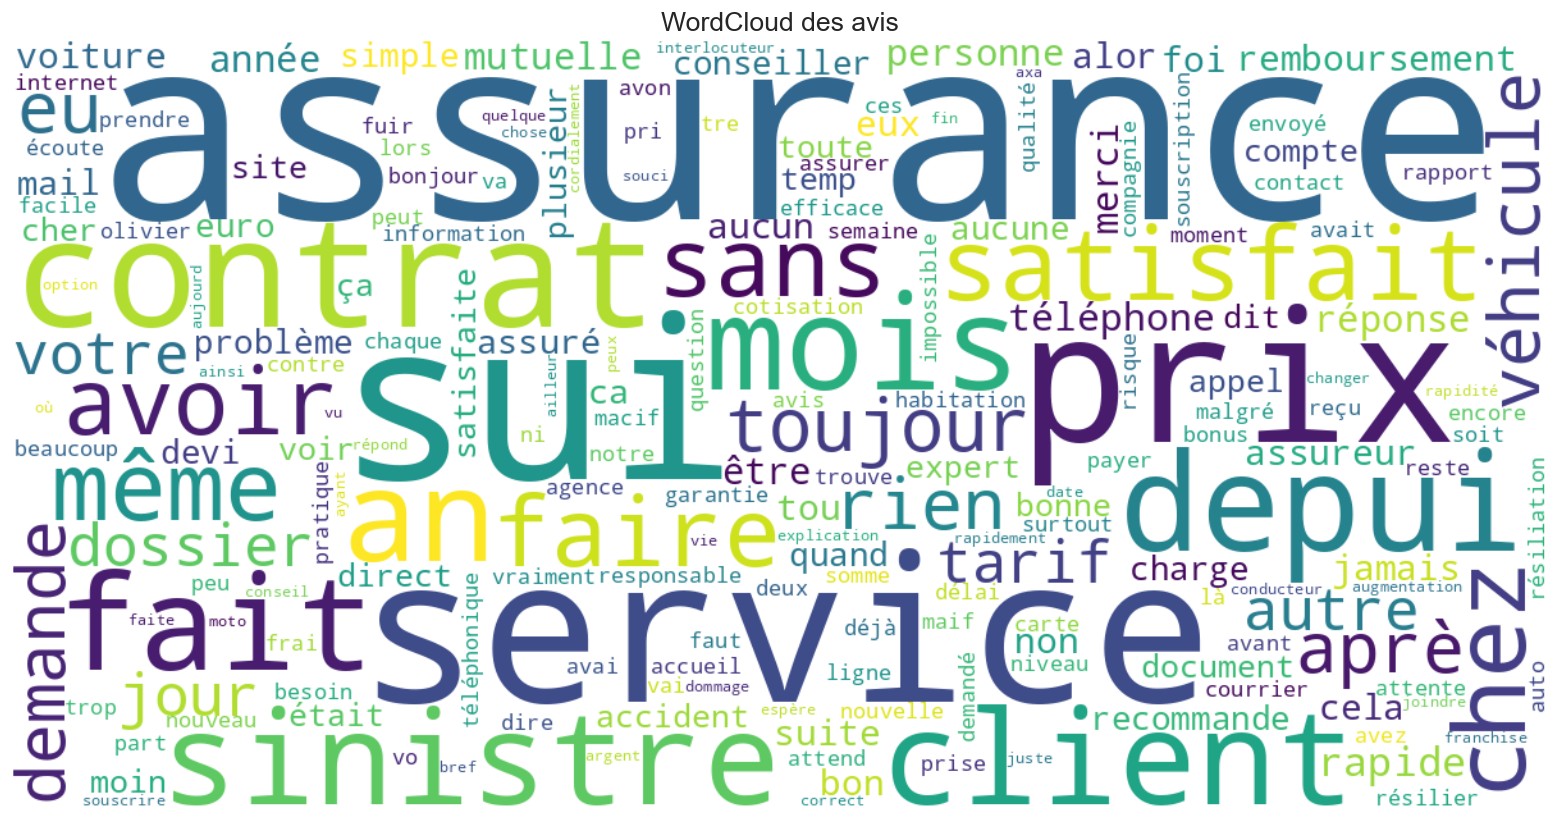

In [14]:
all_text = ' '.join(df[TEXT_COL].fillna('').astype(str))
all_text = re.sub(r'[^\w\s]', ' ', all_text.lower())
all_text = ' '.join(w for w in all_text.split() if len(w) > 1)

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    max_words=200,
    stopwords=set(FR_STOP_WORD),
    collocations=False,
    colormap='viridis'
).generate(all_text)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('WordCloud des avis', fontsize=16)
plt.tight_layout()
plt.show()

## 1.7 Mots fréquents et N-grammes

In [15]:
def get_top_ngrams(corpus, ngram_range, n_top, stop_words):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=stop_words,
                          token_pattern=r'(?u)\b[a-zA-ZÀ-ÿ]{3,}\b')
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)[:n_top]


def plot_ngrams(ngrams, title, color, ax):
    words, counts = zip(*ngrams)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Fréquence')

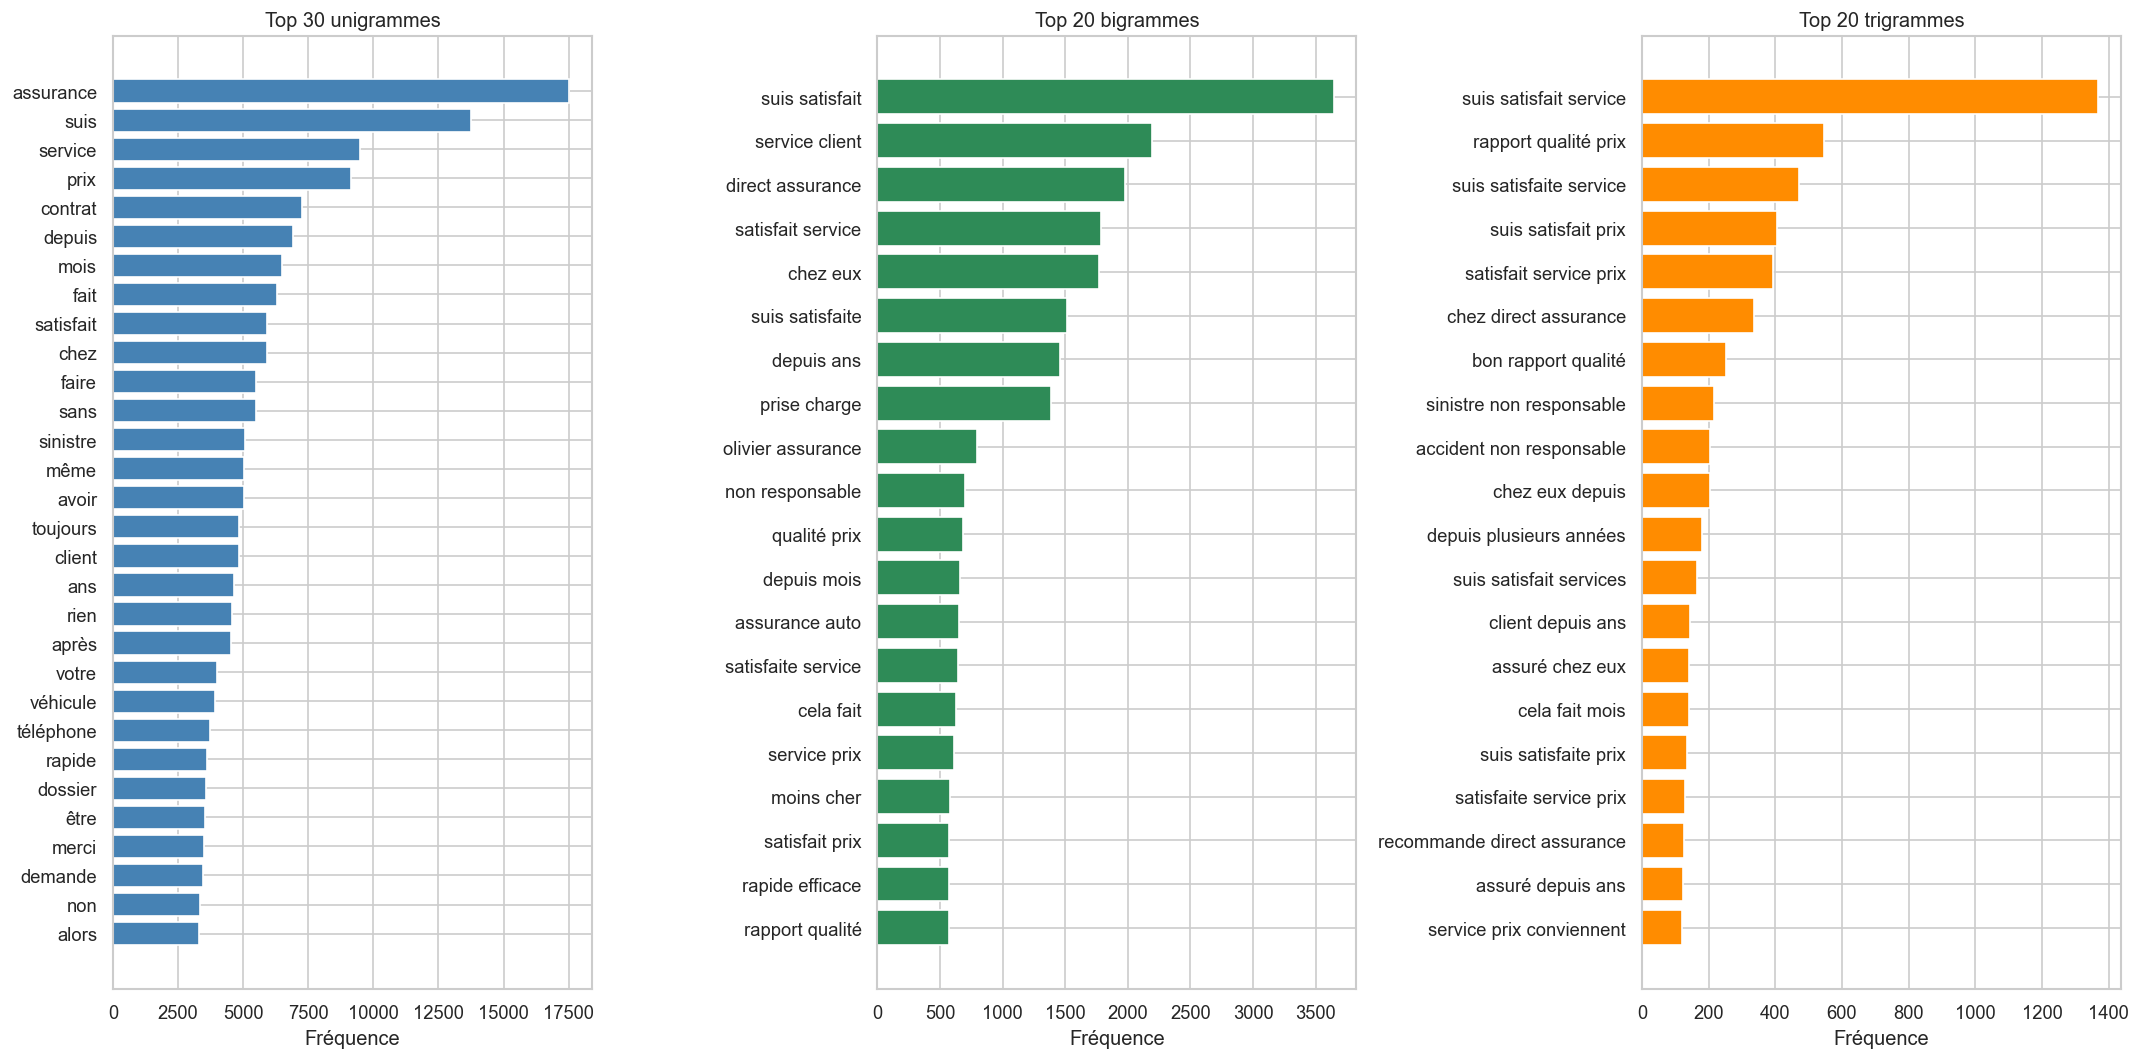

In [16]:
corpus = df[TEXT_COL].fillna('').astype(str).tolist()

top_uni = get_top_ngrams(corpus, (1, 1), 30, FR_STOP_WORD)
top_bi = get_top_ngrams(corpus, (2, 2), 20, FR_STOP_WORD)
top_tri = get_top_ngrams(corpus, (3, 3), 20, FR_STOP_WORD)

fig, axes = plt.subplots(1, 3, figsize=(18, 9))
plot_ngrams(top_uni, 'Top 30 unigrammes', 'steelblue', axes[0])
plot_ngrams(top_bi, 'Top 20 bigrammes', 'seagreen', axes[1])
plot_ngrams(top_tri, 'Top 20 trigrammes', 'darkorange', axes[2])
plt.tight_layout()
plt.show()

## 1.8 Timeline

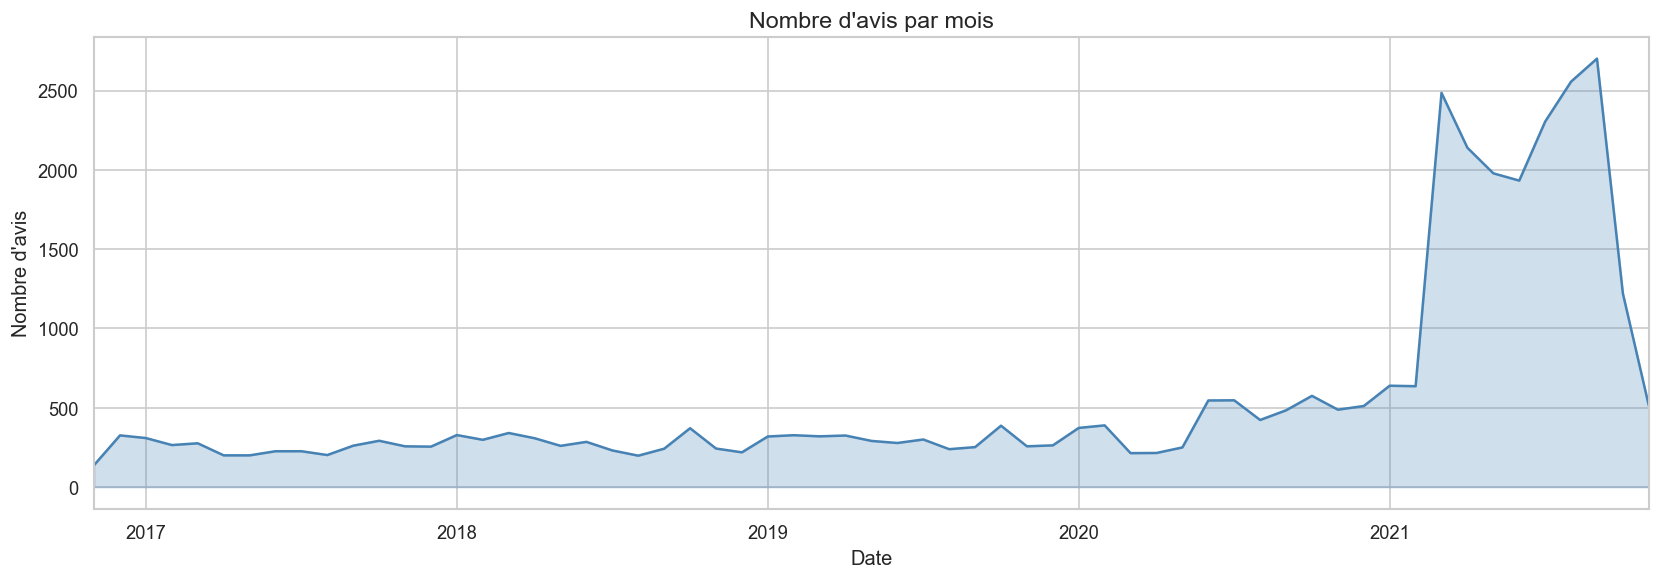

Date range: 2016-11-17 00:00:00 → 2021-11-16 00:00:00
Total months with data: 61


In [17]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce', dayfirst=True)
n_invalid = df[DATE_COL].isna().sum()
if n_invalid > 0:
    print(f'Warning: {n_invalid:,} rows with unparseable dates were dropped from the timeline.')

timeline = df.dropna(subset=[DATE_COL]).set_index(DATE_COL).resample('ME').size()

fig, ax = plt.subplots(figsize=(14, 5))
timeline.plot(ax=ax, color='steelblue', linewidth=1.5)
ax.fill_between(timeline.index, timeline.values, alpha=0.25, color='steelblue')
ax.set_title('Nombre d\'avis par mois', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Nombre d\'avis')
plt.tight_layout()
plt.show()

print(f'Date range: {df[DATE_COL].min()} → {df[DATE_COL].max()}')
print(f'Total months with data: {len(timeline)}')